In [ ]:
! pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"naman2701","key":"e4cbc8d78675ce4dca26d9e2ccb7dde8"}'}

In [ ]:
! mkdir -p ~/.config/kaggle
! mv kaggle.json ~/.config/kaggle
! chmod 600 ~/.config/kaggle/kaggle.json

In [ ]:
! kaggle datasets list

ref                                                        title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
sahilislam007/college-student-placement-factors-dataset    College Student Placement Factors Dataset               110450  2025-07-02 08:33:50.547000           4993        103  1.0              
urvishahir/electric-vehicle-specifications-dataset-2025    Electric Vehicle Specs Dataset (2025)🔋🚗                  16631  2025-06-20 07:14:56.777000           9660        232  1.0              
abdulmalik1518/cars-datasets-2025                          Cars Datasets (2025)                                     25987  2025-07-17 21:43:28.493000           1697         46  1.0              
pratsharma7/student-quiz-

In [ ]:
!kaggle datasets download -d aryagavande/covid-19-tweets-vaccination-and-deaths-data

Dataset URL: https://www.kaggle.com/datasets/aryagavande/covid-19-tweets-vaccination-and-deaths-data
License(s): CC-BY-SA-4.0
  0% 0.00/349k [00:00<?, ?B/s]
100% 349k/349k [00:00<00:00, 830MB/s]


In [ ]:
! unzip -q covid-19-tweets-vaccination-and-deaths-data.zip -d ./covid-19-tweets-vaccination-and-deaths-data

In [ ]:
!pip install tensorflow

In [ ]:
import pandas as pd
import os
os.listdir('covid-19-tweets-vaccination-and-deaths-data')

['Final_Template.html', 'Final_dataset (1).csv']

In [ ]:
df = pd.read_csv("covid-19-tweets-vaccination-and-deaths-data/Final_dataset (1).csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            2000 non-null   object 
 1   daily_deaths                    2000 non-null   int64  
 2   daily_increase_percent          2000 non-null   int64  
 3   user_name                       2000 non-null   object 
 4   country                         2000 non-null   object 
 5   user_created                    2000 non-null   object 
 6   user_followers                  2000 non-null   int64  
 7   user_verified                   2000 non-null   bool   
 8   source                          2000 non-null   object 
 9   is_retweet                      2000 non-null   bool   
 10  text_sentiment                  2000 non-null   int64  
 11  Season                          2000 non-null   object 
 12  user_since_days                 20

In [ ]:
df.head()

,daily_deaths,daily_increase_percent,user_followers,user_verified,is_retweet,text_sentiment,user_since_days,daily_vaccinations,total_vaccinations_per_hundred,label
0,9452,7,633,0,0,1,2782,264585.0,0.93,1
1,9452,7,84,0,0,-1,3936,264585.0,0.93,0
2,15062,0,12,0,0,1,51,372000.0,1.58,1
3,15062,0,2199,0,0,1,4329,372000.0,1.58,1
4,15025,34,3649,0,0,0,4174,333663.0,1.32,0


In [ ]:
print(df.columns.tolist())

['daily_deaths', 'daily_increase_percent', 'user_followers', 'user_verified', 'is_retweet', 'text_sentiment', 'user_since_days', 'daily_vaccinations', 'total_vaccinations_per_hundred', 'label']


In [ ]:
df['label'] = (df['text_sentiment'] == 1).astype(int)

In [ ]:
df = df.drop(columns=[
    'Date', 'user_name', 'country', 'user_created', 'source', 'Season', 'vaccine_group'
], errors='ignore')


In [ ]:
df['user_verified'] = df['user_verified'].astype(int)
df['is_retweet'] = df['is_retweet'].astype(int)


In [ ]:
import numpy as np
df['user_followers'] = np.log1p(df['user_followers'])
df['daily_deaths'] = np.log1p(df['daily_deaths'])
df['daily_vaccinations'] = np.log1p(df['daily_vaccinations'])


In [ ]:
X = df.drop(columns=['text_sentiment', 'label'])
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_scaled, y, test_size=0.1, random_state=42)

In [ ]:
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights = dict(enumerate(weights))

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    Xtrain, Ytrain,
    epochs=50,
    validation_data=(Xtest, Ytest),
    class_weight=class_weights,
    verbose=1
)


Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4665 - loss: 0.6963 - val_accuracy: 0.5050 - val_loss: 0.6907
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5209 - loss: 0.6904 - val_accuracy: 0.5350 - val_loss: 0.6880
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5482 - loss: 0.6909 - val_accuracy: 0.5450 - val_loss: 0.6879
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5623 - loss: 0.6851 - val_accuracy: 0.5700 - val_loss: 0.6870
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5930 - loss: 0.6821 - val_accuracy: 0.5600 - val_loss: 0.6889
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5974 - loss: 0.6783 - val_accuracy: 0.5650 - val_loss: 0.6886
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5738 - loss: 0.6818 - val_accuracy: 0.5300 - val_loss: 0.6890
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5550 - loss: 0.6835 - val_accuracy: 0.5450 - val_loss:

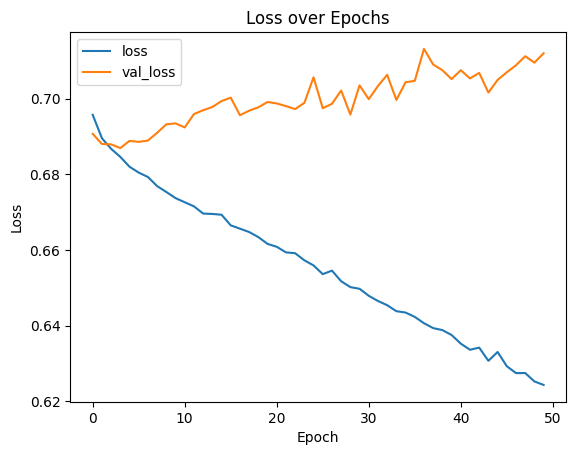

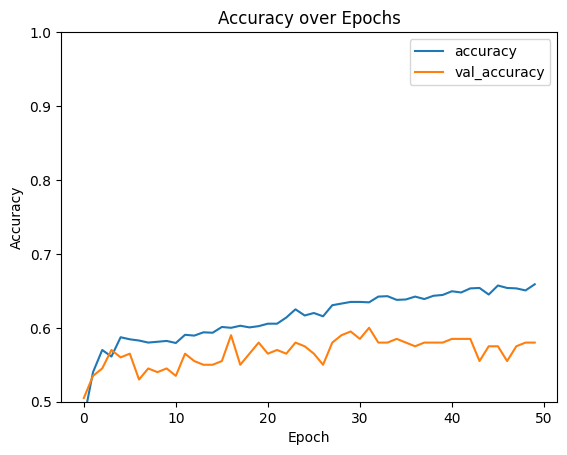


✅ Test Accuracy: 0.5800
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.62      0.61      0.61       110
           1       0.53      0.54      0.54        90

    accuracy                           0.58       200
   macro avg       0.58      0.58      0.58       200
weighted avg       0.58      0.58      0.58       200



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Plot Loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# Plot Accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.ylim([0.5, 1])
plt.legend()
plt.show()

# 5. Final Evaluation
test_loss, test_acc = model.evaluate(Xtest, Ytest, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# 6. Classification Report
y_pred = (model.predict(Xtest) > 0.5).astype(int)
print("\n📊 Classification Report:\n")
print(classification_report(Ytest, y_pred))